# Resumen análisis espacial estático

**Ausencia en target de autocorrelación espacial**: no hay dependencia espacial en ocupación de pisos

**Dependencia espacial en precio, pero ausencia de patrón espacial en puntuación de reseñas**

# 0. Conexión con proyecto e importación de dataset

In [9]:
%load_ext autoreload
%autoreload 2

from spatial import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")
df_barrios = pd.read_csv(r"D:\yannis_data\Descargas\BarcelonaCiutat_Barris.csv")

In [18]:
# 1. Crear el GeoDataFrame manteniendo EPSG:4326 
distritos_gdf = gpd.GeoDataFrame(
    df_barrios, 
    geometry=gpd.points_from_xy(df_barrios.longitude, df_barrios.latitude) if 'lat' in df_barrios else df_barrios['geometria_wgs84'].apply(wkt.loads),
    crs="EPSG:4326")

# 2. Asegurar de que la columna se llame 'geometry' y sea la activa
distritos_gdf = distritos_gdf.set_geometry('geometry')

# 3. Normalizar usando el mismo nombre que espera tu función 
distritos_gdf['key_spatial'] = distritos_gdf['nom_barri'].str.lower().str.strip()

# 4. Agrupar puntos
conteo_barrios = df.groupby('neighbourhood_cleansed').size().reset_index(name='count')
conteo_barrios['key_spatial'] = conteo_barrios['neighbourhood_cleansed'].str.lower().str.strip()

# 5. Merge 
gdf_mapa = distritos_gdf.merge(conteo_barrios, on='key_spatial', how='inner')

In [21]:
# 1. Convertir la columna de texto WKT a objetos geométricos reales
if not isinstance(df_barrios['geometria_wgs84'].iloc[0], (str, bytes)) == False:
    geometrias = df_barrios['geometria_wgs84'].apply(wkt.loads)
else:
    geometrias = df_barrios['geometria_wgs84']

# 2. CREAR EL GEODATAFRAME (Esto es lo que falta para que tenga .crs)
df_barrios = gpd.GeoDataFrame(df_barrios, geometry=geometrias, crs="EPSG:4326")

# 3. Asegurarnos de que la columna se llame 'geometry'
df_barrios = df_barrios.set_geometry('geometry')

df_barrios = df_barrios.drop(columns=['geometria_etrs89', 'geometria_wgs84'], errors='ignore')

# 1. Componente espacial

## 1.1 Variable target

✅ Éxito: Se han vinculado 68 barrios.

🗺️ ANÁLISIS DE AUTOCORRELACIÓN ESPACIAL: is_occupied
🔹 Índice de Moran Global (I): -0.0496
🔹 p-valor: 0.3110
   ⚠️ Conclusión: Distribución ALEATORIA (El espacio no influye).


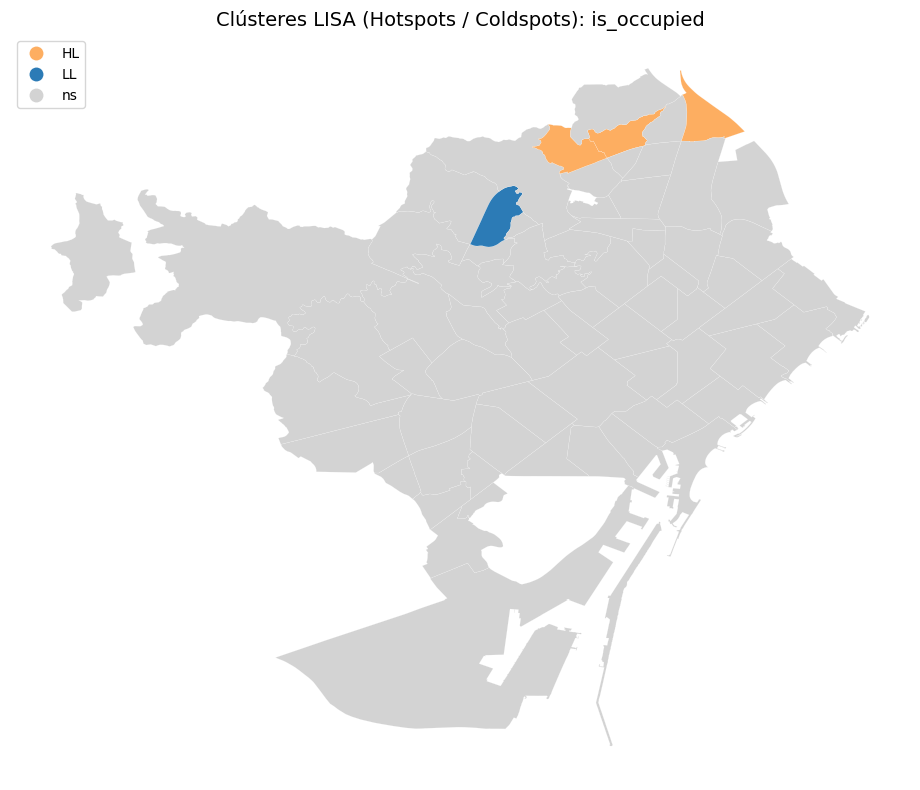


[+] Calculando Semivariograma para is_occupied (Muestra: 5000 puntos)...


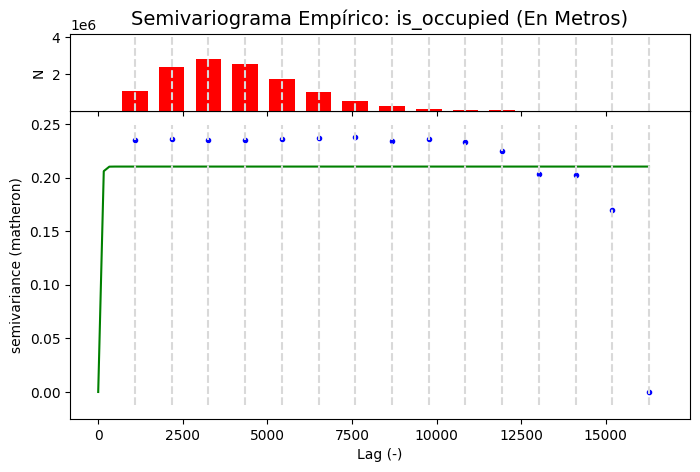

🔹 Rango estimado (Distancia de influencia): ~126 metros.


In [23]:
espacial_target = 'is_occupied'

# Crear el set de datos
gdf_barrios_analisis = prepare_spatial_data(df, df_barrios, espacial_target)

# Ejecutar Moran
run_spatial_autocorrelation(gdf_barrios_analisis, espacial_target)

# 4. Lanzar el Variograma sobre los puntos crudos (muestra aleatoria)
variograma = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
plot_variogram(variograma, 'is_occupied')

## 1.2 Variables predictoras

✅ Éxito: Se han vinculado 68 barrios.

🗺️ ANÁLISIS DE AUTOCORRELACIÓN ESPACIAL: listing_price
🔹 Índice de Moran Global (I): 0.1753
🔹 p-valor: 0.0100
   ✅ Conclusión: Existe CLUSTERING ESPACIAL significativo (Valores similares se atraen).


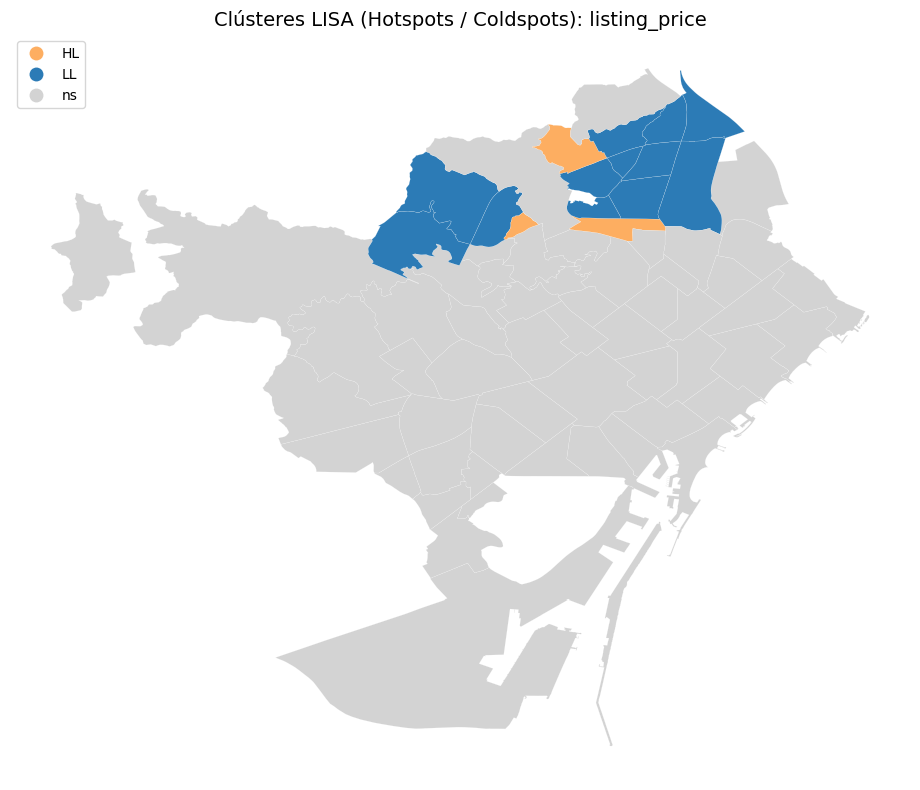


🗺️ ANÁLISIS DE AUTOCORRELACIÓN ESPACIAL: review_scores_rating
🔹 Índice de Moran Global (I): -0.1430
🔹 p-valor: 0.0220
   ✅ Conclusión: Existe DISPERSIÓN ESPACIAL (Patrón de tablero de ajedrez).


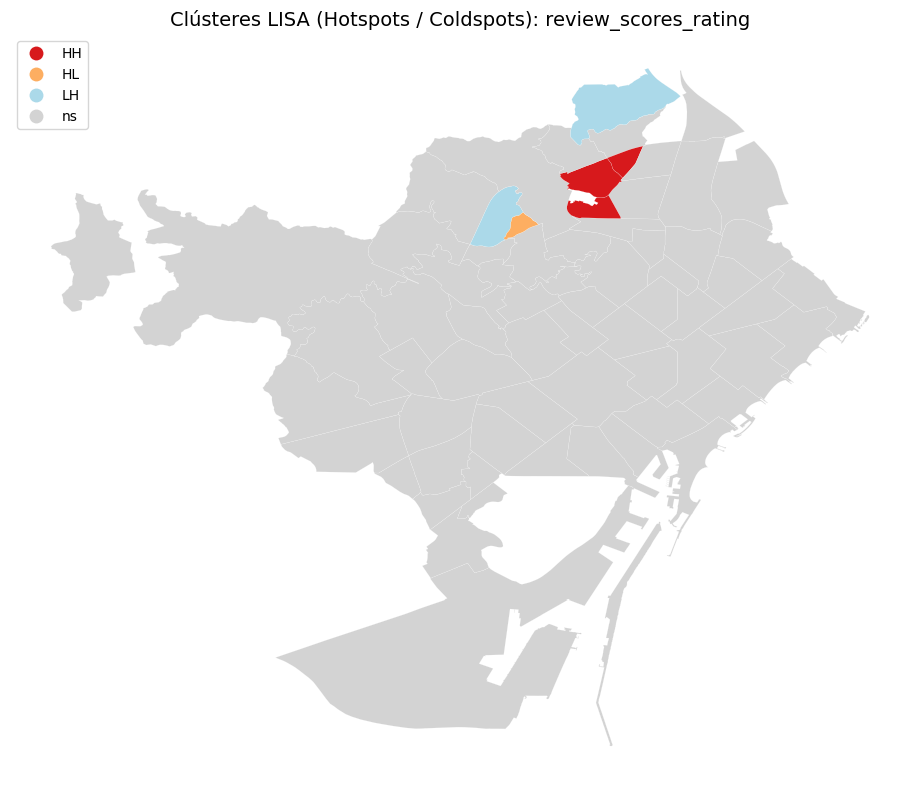

In [26]:
# 1. Definir variables numéricas a analizar espacialmente
vars_espaciales = ['listing_price', 'review_scores_rating']

# 2. Crear el GeoDataFrame agregado por barrios
gdf_barrios_analisis = prepare_spatial_data(df, df_barrios, vars_espaciales)

# 3. Lanzar Moran y LISA para cada variable
for var in vars_espaciales:
    run_spatial_autocorrelation(gdf_barrios_analisis, var)



[+] Calculando Semivariograma para listing_price (Muestra: 5000 puntos)...


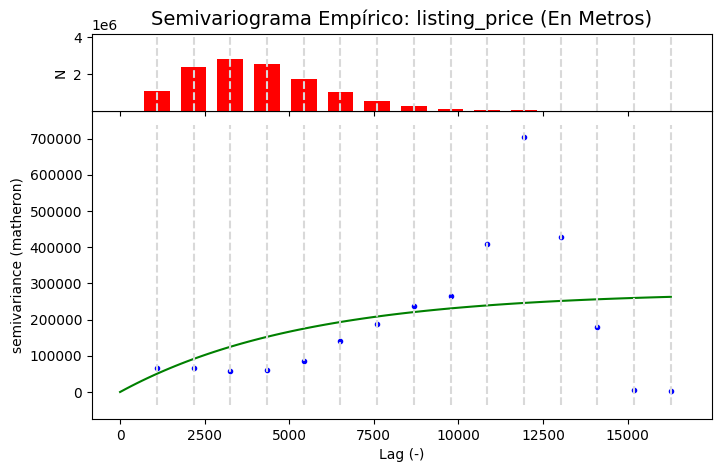

🔹 Rango estimado (Distancia de influencia): ~16280 metros.

[+] Calculando Semivariograma para review_scores_rating (Muestra: 5000 puntos)...


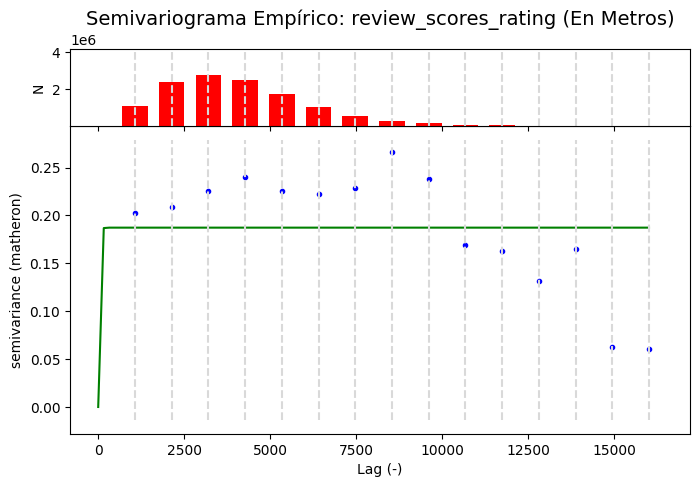

🔹 Rango estimado (Distancia de influencia): ~80 metros.


In [28]:
# 4. Lanzar el Variograma sobre los puntos crudos (muestra aleatoria)
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
plot_variogram(df, 'listing_price')
plot_variogram(df,'review_scores_rating')